# 🎮 Player Churn Analysis and Prediction

In this notebook, we explore the `online_gaming_behavior_dataset.csv`. 
Our goal is to understand what factors lead to a player being 'highly engaged' versus 'churning' (low engagement), and to build a predictive model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('online_gaming_behavior_dataset.csv')
df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


### Data Cleaning and Preprocessing
We will drop the `PlayerID` and map the target variable `EngagementLevel` to a binary Churn indicator. Low engagement means the player is churning.

In [2]:
df = df.drop(columns=['PlayerID'])
df['Churn'] = df['EngagementLevel'].apply(lambda x: 1 if x == 'Low' else 0)
df = df.drop(columns=['EngagementLevel'])

### Encoding Categorical Variables
We convert categorical features like Gender, Location, and Genre to numeric.

In [3]:
gender_map = {val: idx for idx, val in enumerate(df['Gender'].unique())}
df['Gender'] = df['Gender'].map(gender_map)

location_map = {val: idx for idx, val in enumerate(df['Location'].unique())}
df['Location'] = df['Location'].map(location_map)

genre_map = {val: idx for idx, val in enumerate(df['GameGenre'].unique())}
df['GameGenre'] = df['GameGenre'].map(genre_map)

diff_map = {val: idx for idx, val in enumerate(df['GameDifficulty'].unique())}
df['GameDifficulty'] = df['GameDifficulty'].map(diff_map)

### Model Training
Let's split the dataset, scale our features, and train a Random Forest Classifier.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.9485
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      5942
           1       0.92      0.88      0.90      2065

    accuracy                           0.95      8007
   macro avg       0.94      0.92      0.93      8007
weighted avg       0.95      0.95      0.95      8007



### Feature Importance
What features drive player churn the most?

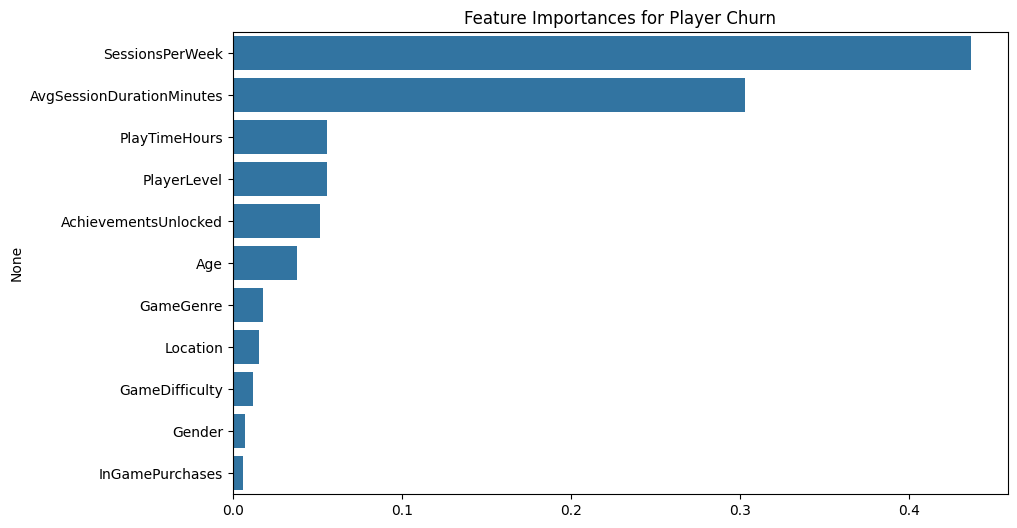

In [5]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title('Feature Importances for Player Churn')
plt.show()

### Save Model and Scaler

In [6]:
import joblib
joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print('Models saved successfully.')

Models saved successfully.


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

y_pred = model.predict(X_test_scaled)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("----- Model Performance -----")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

----- Model Performance -----
Accuracy : 0.9485450231047833
Precision: 0.9214686384497706
Recall   : 0.8750605326876514
F1 Score : 0.8976651763537009

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      5942
           1       0.92      0.88      0.90      2065

    accuracy                           0.95      8007
   macro avg       0.94      0.92      0.93      8007
weighted avg       0.95      0.95      0.95      8007


Confusion Matrix:

[[5788  154]
 [ 258 1807]]
